# Ejecta density profile

Testing of two ejecta density models presented in https://arxiv.org/pdf/1908.05815 (eq. 3)

In [2]:
import importlib
import utils_ejecta_models as u_em
from lal import C_SI, G_SI, PC_SI
importlib.reload(u_em)

from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt


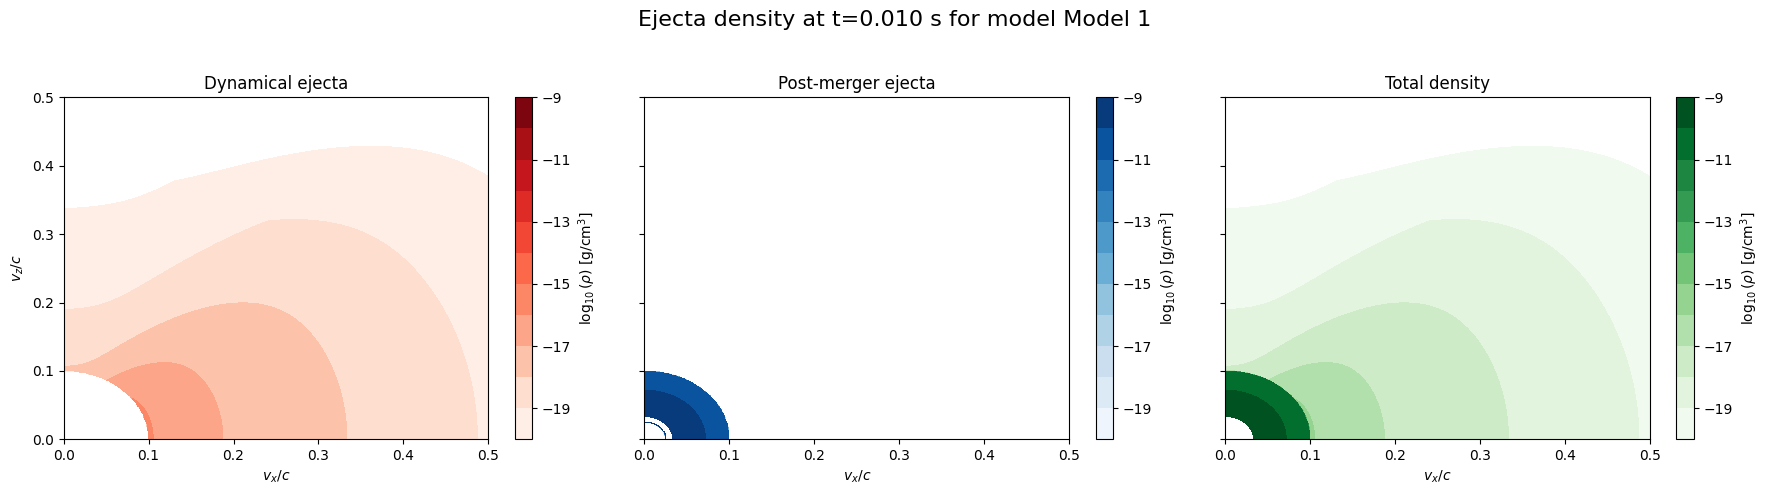

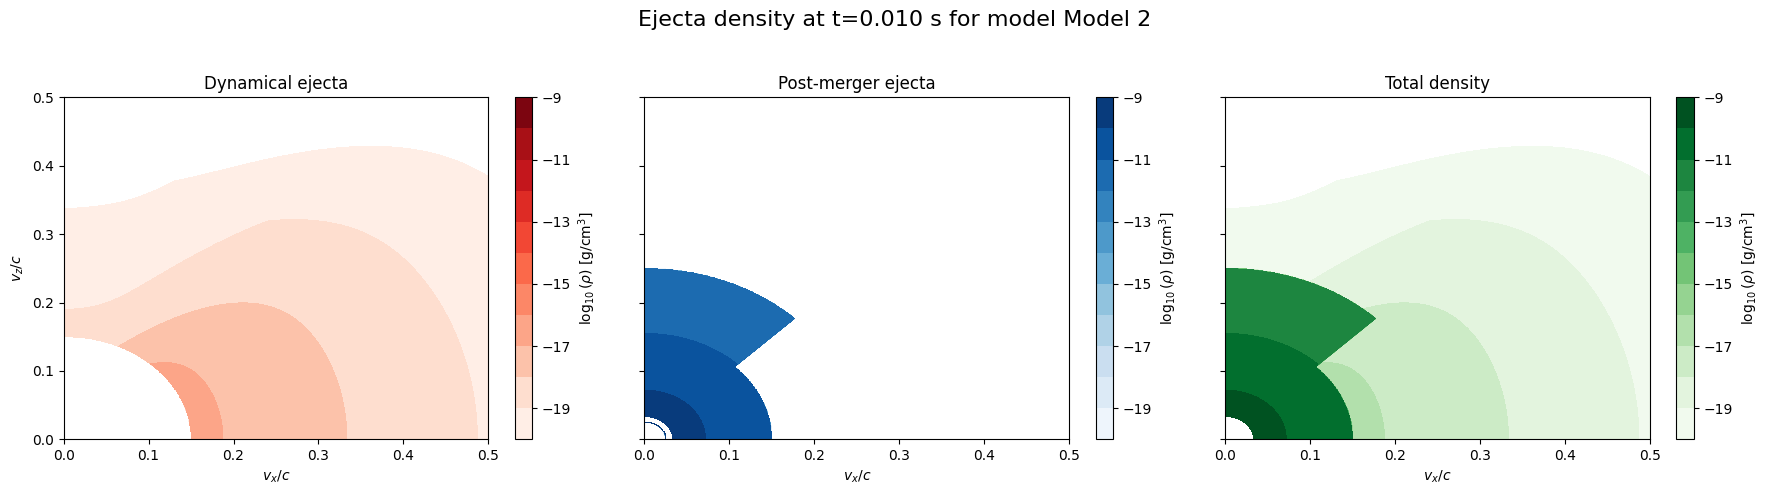

In [24]:
# Model 1 : 
u_em.plot_ejecta_density_grid(u_em.rho_profile_model1, "Model 1", t=0.01, v_pm_min=0.025, v_pm_max=0.1, v_d_min=0.1, v_max=0.9, n=1000)
# Model 2 avec v_pm_max > v_d_min :
u_em.plot_ejecta_density_grid(u_em.rho_profile_model2, "Model 2", t=0.01, v_pm_min=0.025, v_pm_max=0.25, v_d_min=0.15, v_max=0.9, n=1000) 

Test gif pour voir l'évolution temporelle de la densité d'ejecta pour les 2 modèles

In [ ]:
model = u_em.rho_profile_model1  
model_name = "Model 1"
t_values = np.logspace(-2, np.log10(0.5), 30)  # de 0.01s à 0.5s 
v_pm_min = 0.025
v_pm_max = 0.1
v_d_min = 0.1
v_max = 0.9
n = 200
f_d_pol = 0.01

_, ani = u_em.make_ejecta_density_gif(
    model,
    model_name,
    t_values,
    v_pm_min,
    v_pm_max,
    v_d_min,
    v_max,
    n,
    f_d_pol
)

HTML(ani.to_jshtml())

In [15]:
model = u_em.rho_profile_model2  
model_name = "Model 2"
t_values = np.logspace(-2, np.log10(0.5), 30)  # de 0.01s à 0.5s 
v_pm_min = 0.025
v_pm_max = 0.25
v_d_min = 0.15
v_max = 0.9
n = 200
f_d_pol = 0.01

_, ani = u_em.make_ejecta_density_gif(
    model,
    model_name,
    t_values,
    v_pm_min,
    v_pm_max,
    v_d_min,
    v_max,
    n,
    f_d_pol
)

HTML(ani.to_jshtml())

In [ ]:
from IPython.display import HTML
from matplotlib import animation
from matplotlib.animation import PillowWriter
# Paramètres du modèle
model = u_em.rho_profile_model2  
model_name = "Model 2"
t_values = np.logspace(-2, np.log10(0.5), 30)  # de 0.01s à 0.5s 
v_pm_min = 0.025
v_pm_max = 0.25
v_d_min = 0.15
v_max = 0.9
n = 200
f_d_pol = 0.025

vx_grid = np.linspace(0, v_max, n)
vz_grid = np.linspace(0, v_max, n)
VX, VZ = np.meshgrid(vx_grid, vz_grid)
THETA = np.arctan2(VX, VZ)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
titles = ["Dynamical ejecta", "Post-merger ejecta", "Total density"]
cmaps = ['Reds', 'Blues', 'Greens']
ims = []

levels = np.linspace(-20, -9, 12) # densité entre 10-20 et 10-9

def compute_densities(t):
    rho_dyn = np.zeros_like(VX)
    rho_pm = np.zeros_like(VX)
    rho_tot = np.zeros_like(VX)
    for i in range(n):
        for j in range(n):
            v_tot = np.sqrt(VX[i, j]**2 + VZ[i, j]**2)
            r = v_tot * C_SI * t
            theta_val = THETA[i, j]
            dyn, pm, tot = model(r, t, theta_val, v_pm_min, v_pm_max, v_d_min, v_max, f_d_pol)
            rho_dyn[i, j] = dyn
            rho_pm[i, j] = pm
            rho_tot[i, j] = tot
    return rho_dyn, rho_pm, rho_tot

# Initialisation
def init():
    for ax in axes:
        ax.clear()
    for ax, title in zip(axes, titles):
        ax.set_xlabel(r'$v_x/c$')
        ax.set_xlim(0, 0.5)
        ax.set_ylim(0, 0.5)
        ax.set_title(title)
    axes[0].set_ylabel(r'$v_z/c$')
    return axes

# Animation update
def animate(frame):
    t = t_values[frame]
    rho_dyn, rho_pm, rho_tot = compute_densities(t)
    datas = [rho_dyn, rho_pm, rho_tot]
    for ax, data, cmap in zip(axes, datas, cmaps):
        ax.clear()
        im = ax.contourf(VX, VZ, np.log10(data + 1e-30), levels=levels, cmap=cmap)
        ax.set_xlabel(r'$v_x/c$')
        ax.set_xlim(0, 0.5)
        ax.set_ylim(0, 0.5)
    axes[0].set_ylabel(r'$v_z/c$')
    axes[0].set_title("Dynamical ejecta")
    axes[1].set_title("Post-merger ejecta")
    axes[2].set_title("Total density")
    fig.suptitle(f"Ejecta density at t={t:.3f} s for {model_name}", fontsize=16)
    return axes

ani = animation.FuncAnimation(fig, animate, frames=len(t_values), init_func=init, blit=False, interval=250)
outdir = 'ejecta_density_plot'
writer = PillowWriter(fps=8)
ani.save(f'{outdir}/ejecta_density_{model_name.replace(" ", "_")}.gif', writer=writer, dpi=200)
plt.close(fig)
HTML(ani.to_jshtml())

Comparison of the radial density profile of the dynamical ejecta

1.1387714488749304e-27


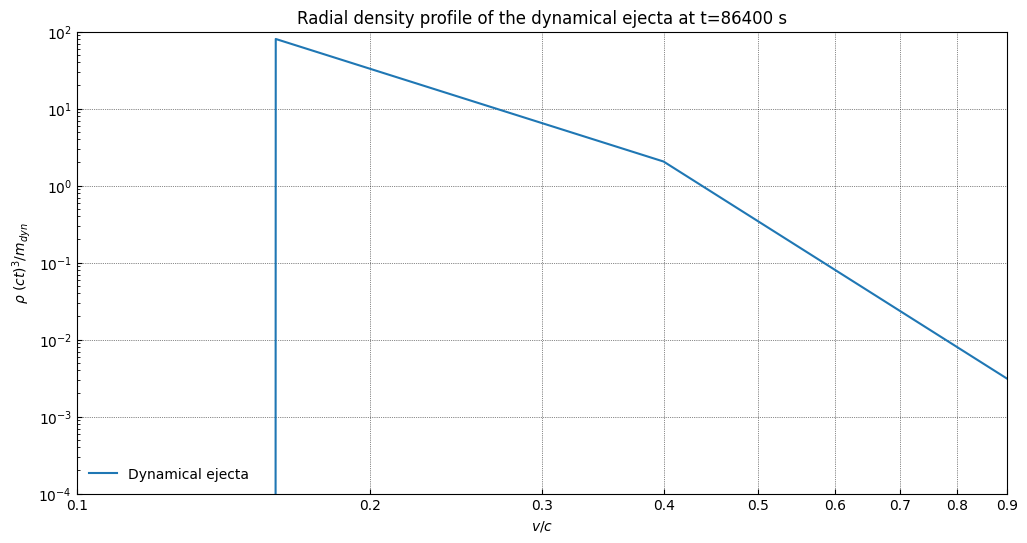

In [16]:
from lal import C_SI
importlib.reload(u_em)
plt.figure(figsize=(12, 6))
v = np.arange(0.1, 0.91, 0.01)

t = 86400 # en secondes
r = v * t * C_SI   # r en mètres

rho_dyn_v = np.array([
    u_em.rho_profile_model1(r_i, t, np.pi/2, v_pm_min=0.025, v_pm_max=0.1, v_d_min=0.15, v_max=0.99)[0]
    for r_i in r
])

# Normalisation comme fig.3
rho_norm = rho_dyn_v * (C_SI * t)**3 
mass_eject,_,_ = u_em.compute_ejecta_mass(
    u_em.rho_profile_model1,
    t, 
    theta=np.pi/2,
    v_pm_min=0.025, v_pm_max=0.1, v_d_min=0.2, v_max=0.9
)

mass_interp = np.interp(v, mass_eject[:,0], mass_eject[:,1])

mass_eject = np.column_stack((v, mass_interp))
print(mass_eject[-1,1])

plt.loglog(v, rho_norm / mass_eject[-1,1] , label='Dynamical ejecta')
plt.xlabel(r'$v/c$')
plt.ylabel(r'$\rho~(c t)^3/m_{dyn}$')
plt.title(f'Radial density profile of the dynamical ejecta at t={t} s')

xticks = np.arange(0.1, 1.0, 0.1)
plt.xticks(xticks, [f"{x:.1f}" for x in xticks])
plt.legend(loc='lower left',frameon=False)
plt.grid(ls='dotted', color='black', alpha=0.9, lw=0.5)
plt.tick_params(axis='both', which='both', direction='in')
plt.xlim(0.1, 0.9)
plt.ylim(1e-4, 1e2)
plt.show()

### Compute the mass for a given density profile and viewing angle

In [ ]:
importlib.reload(u_em)
t = 10 * 24 * 3600 # s
mass_dyn,_,_ = u_em.compute_total_ejecta_mass_norm(
    u_em.rho_profile_model1,
    t,
    v_pm_min=0.025, v_pm_max=0.1, v_d_min=0.15, v_max=0.9
)

/tmp/ipykernel_6645/3194180111.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best', frameon=False)


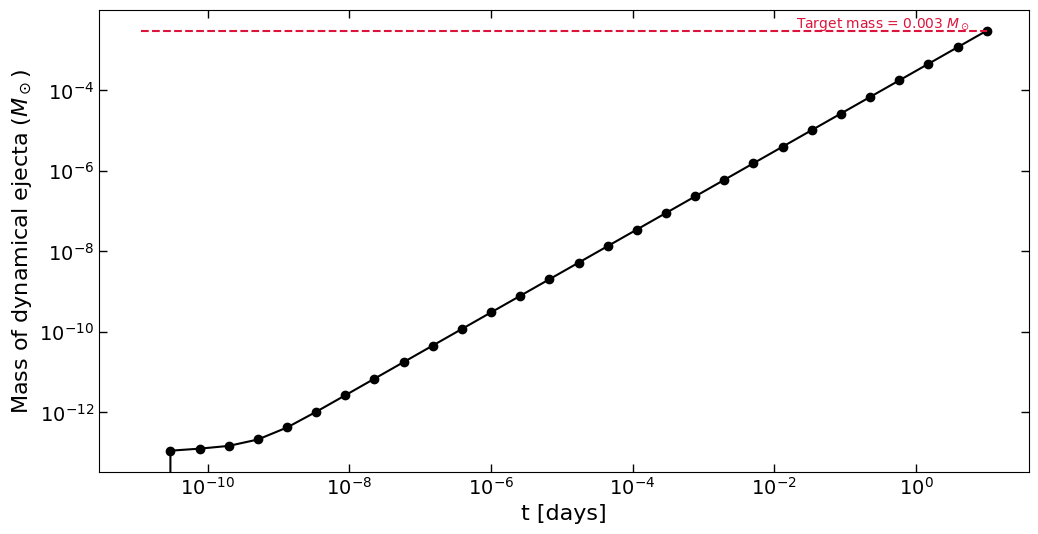

In [ ]:
# Plot for a range of t values from 0.01s to 10 days
t_values = np.logspace(-6, np.log10(10 * 24 * 3600), 30) # in s
plt.figure(figsize=(12, 6))
t_days = []
mass_dyns = []

for t in t_values:
    mass_dyn, _, _ = u_em.compute_total_ejecta_mass_norm(
        u_em.rho_profile_model1,
        t,
        v_pm_min=0.025, v_pm_max=0.1, v_d_min=0.15, v_max=0.9
    )
    t_days.append(t / 86400)
    mass_dyns.append(mass_dyn)

plt.loglog(t_days, mass_dyns, 'o-', markersize=6, color='k')

plt.xlabel('t [days]')
plt.ylabel(r'Mass of dynamical ejecta ($M_\odot$)')
plt.hlines(0.003, xmin=min(t_days), xmax=max(t_days), colors='crimson', linestyles='dashed')
plt.text(0.02, 0.0035, 'Target mass = 0.003 $M_\odot$', color='crimson', fontsize=10)
plt.legend(loc='best', frameon=False)

plt.show()

Test plot 3D de la densité d'éjecta (check si ejecta dynamique est bien equatorial)

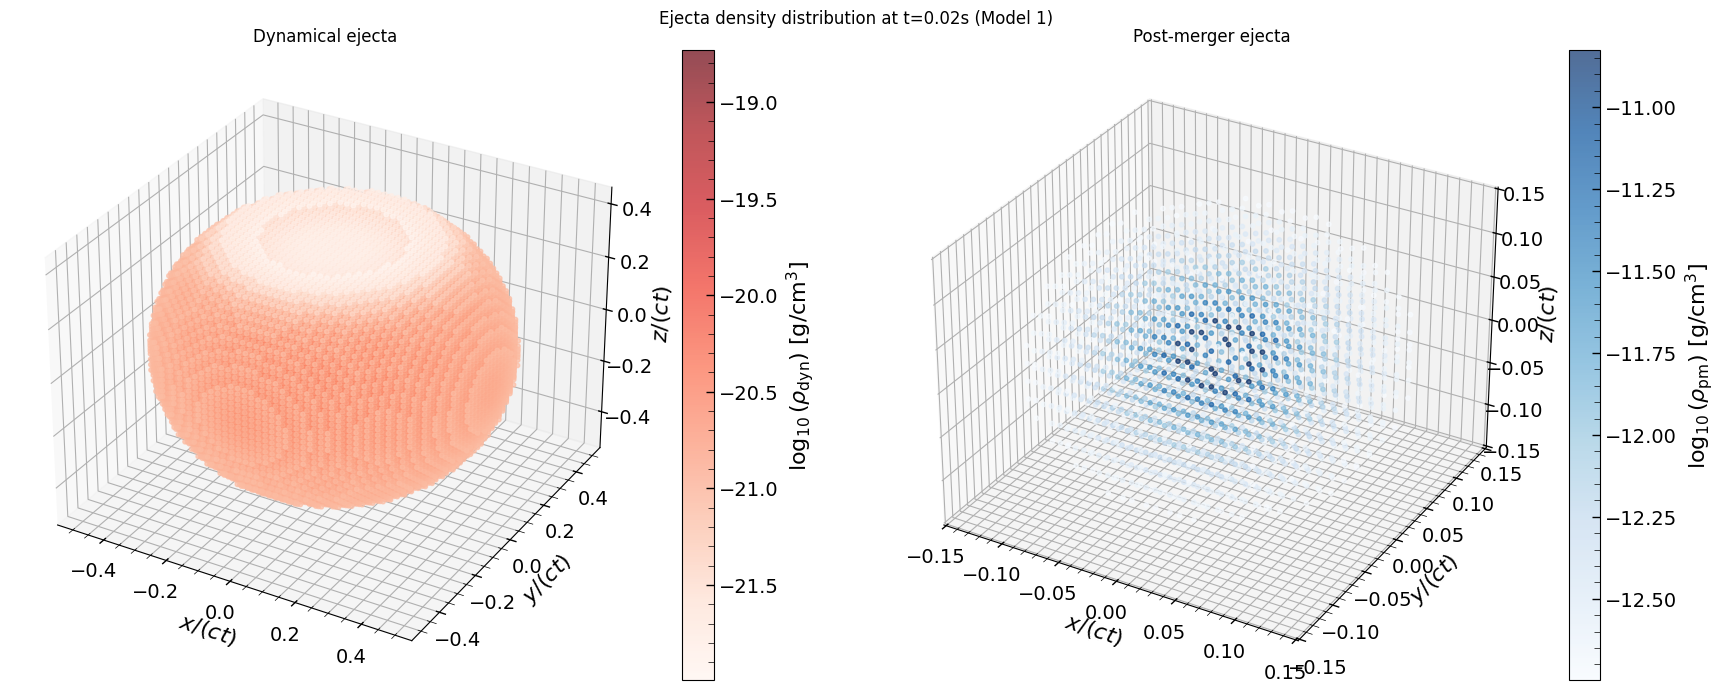

In [7]:
from mpl_toolkits.mplot3d import Axes3D  
t = 0.02
v_pm_min = 0.025
v_pm_max = 0.15
v_d_min = 0.15
v_max = 0.5
n = 50
f_d_pol = 0.025

# Grille en x, y, z centrée en 0
L = v_max * C_SI * t
x = np.linspace(-L, L, n)
y = np.linspace(-L, L, n)
z = np.linspace(-L, L, n)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Conversion en coordonnées sphériques
R = np.sqrt(X**2 + Y**2 + Z**2) # R = rayon
THETA = np.arccos(np.clip(Z / (R + 1e-30), -1, 1))  # éviter division par 0 

# Calcul des densités
rho_dyn = np.zeros_like(R)
rho_pm = np.zeros_like(R)
for i in range(n):
    for j in range(n):
        for k in range(n):
            r = R[i, j, k]
            theta = THETA[i, j, k]
            dyn, pm, _ = u_em.rho_profile_model1(r, t, theta, v_pm_min, v_pm_max, v_d_min, v_max, f_d_pol)
            rho_dyn[i, j, k] = dyn
            rho_pm[i, j, k] = pm

# Masques pour ne garder que les points significatifs
mask_dyn = rho_dyn > 1e-22
mask_pm = rho_pm > 1e-22

# Plot 3D scatter côte à côte
fig = plt.figure(figsize=(18, 7))

# Dynamical ejecta - suppose que l'éjecta se déplace à une vitesse v = r/t, donc on normalise par ct pour avoir une échelle de vitesse
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(
    X[mask_dyn]/(C_SI*t), Y[mask_dyn]/(C_SI*t), Z[mask_dyn]/(C_SI*t),
    c=np.log10(rho_dyn[mask_dyn]), cmap='Reds', s=10, alpha=0.7
)
ax1.set_title("Dynamical ejecta")
ax1.set_xlabel(r'$x/(ct)$')
ax1.set_ylabel(r'$y/(ct)$')
ax1.set_zlabel(r'$z/(ct)$')
fig.colorbar(sc1, ax=ax1, label=r'$\log_{10}(\rho_\mathrm{dyn})$ [g/cm$^3$]')

# Post-merger ejecta
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(
    X[mask_pm]/(C_SI*t), Y[mask_pm]/(C_SI*t), Z[mask_pm]/(C_SI*t),
    c=np.log10(rho_pm[mask_pm]), cmap='Blues', s=10, alpha=0.7
)
ax2.set_title("Post-merger ejecta")
ax2.set_xlabel(r'$x/(ct)$')
ax2.set_ylabel(r'$y/(ct)$')
ax2.set_zlabel(r'$z/(ct)$')
fig.colorbar(sc2, ax=ax2, label=r'$\log_{10}(\rho_\mathrm{pm})$ [g/cm$^3$]')
plt.suptitle(f"Ejecta density distribution at t={t}s (Model 1)")
plt.tight_layout()
plt.show()